These first two code chunks are just to download some code packages to run our analysis. To run each chunk simply click the 'play' arrow and wait for the command to run. You'll know a step is complete when you see a green checkmark to the left of the code chunk.

#Look into adding API access to stream data

#Add text chunks throughout



This cell installs the `neonutilities` package, which is essential for working with NEON (National Ecological Observatory Network) data. It allows us to easily download, stack, and process NEON data products.

In [1]:
pip install neonutilities


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 4.2 MB/s eta 0:00:00


Here we import all the necessary Python libraries for data manipulation, plotting, and interacting with the NEON data:
- `neonutilities as nu`: For NEON data access and processing.
- `matplotlib.pyplot as plt`: For creating static, interactive, and animated visualizations.
- `pandas as pd`: For data manipulation and analysis, especially with DataFrames.
- `numpy as np`: For numerical operations, especially with arrays.
- `datetime`: For handling date and time objects.
- `os`: For interacting with the operating system, like file paths.
- `seaborn as sns`: For creating informative and attractive statistical graphics.

In [54]:
import neonutilities as nu
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import os
import seaborn as sns # Import seaborn for statistical plotting

This code uses `nu.zips_by_product` from `neonutilities` to download eddy covariance data (Data Product ID `DP4.00200.001`) for two sites: Niwot Ridge (NIWO) and Harvard Forest (HARV). The data covers June to July 2018. The `check_size=False` argument is used to bypass file size checks, which can sometimes cause issues with large downloads.

In [3]:
nu.zips_by_product(dpid="DP4.00200.001", package="basic",
              site=["NIWO","HARV"],
              startdate="2018-06", enddate="2018-07",
              savepath=os.getcwd(),
              check_size=False)

100%|██████████| 4/4 [00:17<00:00,  4.48s/it]


After downloading the zipped data, `nu.stack_eddy` is used to extract and combine the eddy covariance files into a more usable format (a dictionary of pandas DataFrames). `filepath=os.getcwd() + "/filesToStack00200"` specifies the directory where the downloaded files are located, and `level="dp04"` indicates that we are stacking data product level 4 (eddy covariance data).

In [4]:
flux = nu.stack_eddy(filepath=os.getcwd() + "/filesToStack00200",
                 level="dp04")

Stacking files by month: 100%|██████████| 2/2 [00:00<00:00, 428.21it/s]


This line simply prints the keys of the `flux` dictionary. Since `nu.stack_eddy` stacks data by site, the keys are typically the site IDs (e.g., 'HARV', 'NIWO'), along with metadata keys like 'variables', 'objDesc', etc. This helps in understanding what data is available in the `flux` object.

In [5]:
flux.keys()

dict_keys(['HARV', 'NIWO', 'variables', 'objDesc', 'issueLog', 'citation_00200_RELEASE-2026'])

This displays the first few rows (head) of the eddy covariance data for the NIWO site. It provides a quick glance at the columns and the initial data points, including `timeBgn`, `timeEnd`, and various flux measurements like `data.fluxCo2.nsae.flux`.

In [6]:
flux['NIWO'].head

<bound method NDFrame.head of                        timeBgn                   timeEnd  \
0    2018-06-01 00:00:00+00:00 2018-06-01 00:29:59+00:00   
1    2018-06-01 00:30:00+00:00 2018-06-01 00:59:59+00:00   
2    2018-06-01 01:00:00+00:00 2018-06-01 01:29:59+00:00   
3    2018-06-01 01:30:00+00:00 2018-06-01 01:59:59+00:00   
4    2018-06-01 02:00:00+00:00 2018-06-01 02:29:59+00:00   
...                        ...                       ...   
2923 2018-07-31 21:30:00+00:00 2018-07-31 21:59:59+00:00   
2924 2018-07-31 22:00:00+00:00 2018-07-31 22:29:59+00:00   
2925 2018-07-31 22:30:00+00:00 2018-07-31 22:59:59+00:00   
2926 2018-07-31 23:00:00+00:00 2018-07-31 23:29:59+00:00   
2927 2018-07-31 23:30:00+00:00 2018-07-31 23:59:59+00:00   

      data.fluxCo2.nsae.flux  data.fluxCo2.stor.flux  data.fluxCo2.turb.flux  \
0                   0.189560               -0.063495                0.253055   
1                   0.942993                0.097496                0.845497   
2                   0.510189                0.025258                0.484930   
3                   0.798080                0.233416                0.564664   
4                   0.434552                0.174156                0.260397   
...                      ...                     ...                     ...   
2923               -1.849725                0.003706               -1.853431   
2924               -1.650256                0.014487               -1.664742   
2925               -2.103625                0.013469               -2.117095   
2926               -1.753846                0.026937               -1.780783   
2927               -3.987323               -0.055449               -3.931874   

      data.fluxH2o.nsae.flux  data.fluxH2o.stor.flux  data.fluxH2o.turb.flux  \
0                  16.428558                3.344588               13.083971   
1                   7.965026               -1.515096                9.480122   
2                   5.387009               -4.262339                9.649348   
3                   9.933795                0.150831                9.782964   
4                   2.963931               -0.016682                2.980613   
...                      ...                     ...                     ...   
2923               65.922289                1.947653               63.974637   
2924               47.721826                0.780033               46.941792   
2925               56.669021                1.766104               54.902917   
2926               54.107876                0.473370               53.634506   
2927              106.480353                0.519059              105.961295   

      data.fluxMome.turb.veloFric  data.fluxTemp.nsae.flux  ...  \
0                        0.202530                 4.782317  ...   
1                        0.192236                -0.598104  ...   
2                        0.119761                -4.342895  ...   
3                        0.119034               -12.651614  ...   
4                        0.158926                -5.054431  ...   
...                           ...                      ...  ...   
2923                     0.272701                40.059811  ...   
2924                     0.242474                28.024341  ...   
2925                     0.210558                19.930836  ...   
2926                     0.218485                32.030578  ...   
2927                     0.282610                86.478975  ...   

      qfqm.fluxCo2.stor.qfFinl  qfqm.fluxCo2.turb.qfFinl  \
0                            1                         1   
1                            1                         1   
2                            1                         1   
3                            1                         1   
4                            1                         1   
...                        ...                       ...   
2923                         1                         1   
2924                         1            

These lines extract unique terms from the column names of the NIWO flux data. This is done to help in filtering the `objDesc` DataFrame later, to find relevant metadata descriptions for the variables present in the `flux` data.

In [7]:
termlist = [f.split('.') for f in flux['NIWO'].keys()]
term = [t for sublist in termlist for t in sublist]

This code filters the `objDesc` DataFrame (which contains descriptions of all NEON data product objects/variables) to show only the descriptions for the terms found in the `flux` data's column names. This helps in understanding what each variable in our dataset represents.

In [8]:
objDesc = flux['objDesc']
objDesc[objDesc['Object'].isin(term)]

,Object,Description
21,angZaxsErth,Wind direction
83,data,Represents data fields
90,distReso,Resolution of vector of distances (units = m)
91,distXaxs90,Distance of 90% contriubtion of footprint alig...
92,distXaxsMax,Max distance of footprint contriubtion aligned...
93,distYaxs90,Distance of 90% contriubtion of footprint alig...
94,distZaxsAbl,Atmospheric boundary layer height used in flux...
99,distZaxsMeasDisp,Measurement height minus displacement height
100,distZaxsRgh,Roughness length used in flux footprint calcul...
124,flux,General term for flux


This displays the `variables` DataFrame from the `flux` dictionary. This DataFrame provides more detailed metadata for each variable, including its category, system variable name, statistical type, and units. It's crucial for correctly interpreting the data.

In [9]:
flux['variables']

,category,system,variable,stat,units
0,data,fluxCo2,nsae,timeBgn,NA
1,data,fluxCo2,nsae,timeEnd,NA
2,data,fluxCo2,nsae,flux,umolCo2 m-2 s-1
3,data,fluxCo2,stor,timeBgn,NA
4,data,fluxCo2,stor,timeEnd,NA
...,...,...,...,...,...
73,qfqm,fluxTemp,turb,timeEnd,NA
74,qfqm,fluxTemp,turb,qfFinl,NA
75,qfqm,foot,turb,timeBgn,NA
76,qfqm,foot,turb,timeEnd,NA


This creates a basic scatter plot of CO2 flux (`data.fluxCo2.nsae.flux`) over time (`timeBgn`) for the NIWO site. The `plt.ylim` sets the y-axis limits to focus on the typical range of flux values. This initial plot gives a raw visualization of the CO2 exchange.

(-20.0, 20.0)

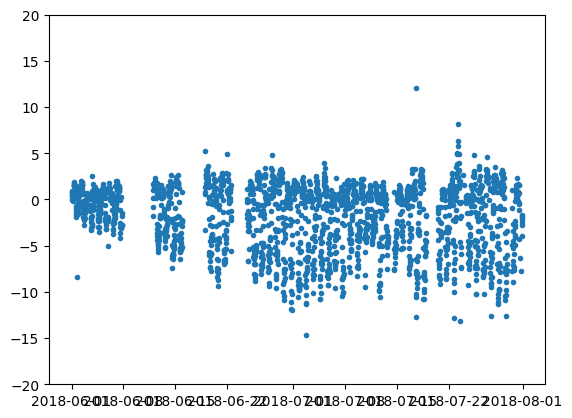

In [10]:
plt.scatter(flux['NIWO'].timeBgn,
            flux['NIWO']['data.fluxCo2.nsae.flux'],
           marker='.')
plt.ylim((-20,20))

In [11]:
plt.show()

This cell refines the previous scatter plot by adding `plt.xlim` to zoom into a specific two-day period (July 7th to July 9th, 2018). This allows for a more detailed examination of the diurnal patterns in CO2 flux, helping to visualize daily cycles of carbon uptake and release.

(np.float64(17719.0), np.float64(17721.0))

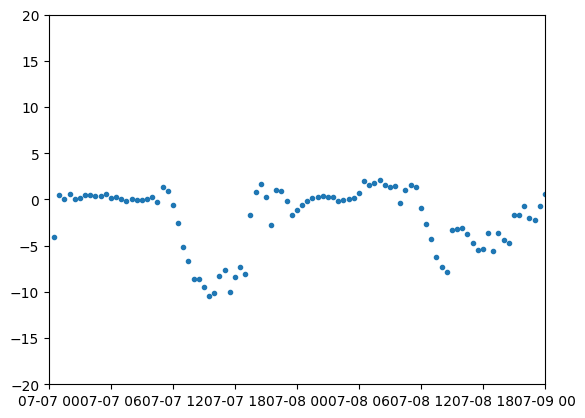

In [12]:
plt.scatter(flux['NIWO'].timeBgn,
            flux['NIWO']['data.fluxCo2.nsae.flux'],
           marker='.')
plt.ylim((-20,20))

plt.xlim((datetime.strptime('2018-07-07 00:00:00', '%Y-%m-%d %H:%M:%S'),
          datetime.strptime('2018-07-09 00:00:00', '%Y-%m-%d %H:%M:%S')))

This downloads Photosynthetically Active Radiation (PAR) data (Data Product ID `DP1.00024.001`) for the NIWO site, covering the same June-July 2018 period. PAR is a critical environmental variable for understanding CO2 flux, as it drives photosynthesis.

In [13]:
pr = nu.load_by_product("DP1.00024.001", site="NIWO",
                    timeindex=30, package="basic",
                    startdate="2018-06", enddate="2018-07",
                    check_size=False)

100%|██████████| 3/3 [00:00<00:00, 19.26it/s]


These lines process the downloaded PAR data:
- `par30 = pr['PARPAR_30min']`: Extracts the 30-minute averaged PAR data.
- `par30['timeBgn'] = par30['startDateTime']`: Creates a `timeBgn` column for merging with flux data.
- `prtop = par30[par30['verticalPosition']=='040']`: Filters for PAR measurements at a specific vertical position (e.g., 40 meters), which is typically representative of canopy-top radiation.

In [14]:
par30 = pr['PARPAR_30min']
par30['timeBgn'] = par30['startDateTime']
prtop = par30[par30['verticalPosition']=='040']

This merges the NIWO eddy covariance flux data (`flux['NIWO']`) with the processed PAR data (`prtop`) based on the `timeBgn` column. The `how='outer'` merge ensures that all time points from both datasets are included, and `on='timeBgn'` specifies the common column for merging. This combined DataFrame (`fxpr`) is crucial for analyzing the relationship between light and CO2 exchange.

In [15]:
fxpr = pd.merge(flux['NIWO'], prtop, how='outer', on='timeBgn')

This code generates a scatter plot of CO2 flux versus PAR for the NIWO site. Key features:
- `plt.scatter()`: Creates the scatter plot.
- `plt.ylim((-20,20))`: Sets the y-axis limits for CO2 flux.
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`: Adds descriptive labels and a title.
- `plt.grid()`: Adds a grid for readability.
- `plt.axhline(0, color='gray', linestyle='--')`: Draws a horizontal line at y=0, which is important for distinguishing between net carbon uptake (negative flux) and release (positive flux).

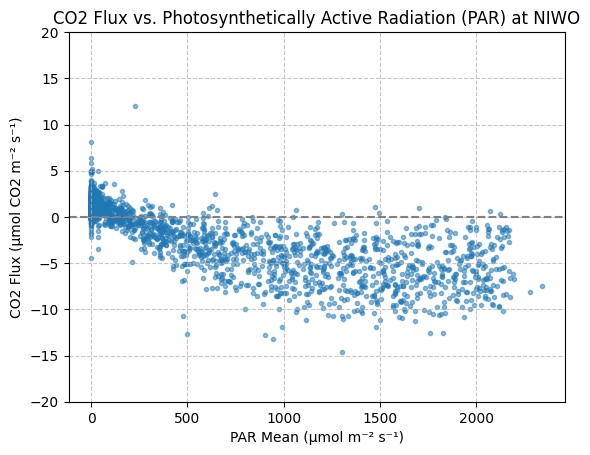

In [44]:
plt.scatter(fxpr.PARMean,
            fxpr['data.fluxCo2.nsae.flux'],
           marker='.', alpha=0.5)
plt.ylim((-20,20))
plt.title('CO2 Flux vs. Photosynthetically Active Radiation (PAR) at NIWO')
plt.xlabel('PAR Mean (µmol m⁻² s⁻¹)')
plt.ylabel('CO2 Flux (µmol CO2 m⁻² s⁻¹)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='gray', linestyle='--') # Add a line at y=0 for sink/source reference
plt.show()

This cell attempts to load data product level 3 (DP03) eddy covariance data using `nu.stack_eddy`. This data product typically includes higher-frequency raw data or different processing levels compared to DP04. This command previously raised a `ValueError` related to inhomogeneous array shapes during stacking, indicating an issue with combining the specific DP03 files. This product is not used in the subsequent analysis of DP04 (flux) and DP01 (PAR).

In [55]:
prof = nu.stack_eddy(filepath=os.getcwd() + "/filesToStack00200",
                 level="dp03")

Joining data variables by file: 100%|██████████| 4/4 [00:00<00:00, 10.51it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

This is a critical setup cell for interacting with the Gemini API:
- `import google.generativeai as genai`: Imports the Google Generative AI SDK.
- `from google.colab import userdata`: Imports `userdata` for secure API key management in Colab.
- `GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')`: Retrieves the API key stored in Colab secrets (named `GOOGLE_API_KEY`).
- `genai.configure(api_key=GOOGLE_API_KEY)`: Configures the Generative AI SDK with your API key.
- `model = genai.GenerativeModel("gemini-2.5-flash")`: Initializes the Gemini model to be used for generating responses.
- `def build_neon_context(...)`: Defines a helper function to create a comprehensive context string about the NEON data. This context includes site information, data product details, variable metadata, sample data rows, and descriptive statistics. It's designed to provide the AI with sufficient background to answer ecological questions accurately.
- `NEON_CONTEXT = build_neon_context(flux, objDesc, site="NIWO")`: Calls the `build_neon_context` function to create the context for the NIWO site, storing it in the `NEON_CONTEXT` variable.

In [45]:
import google.generativeai as genai
from google.colab import userdata

GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel("gemini-2.5-flash")

def build_neon_context(flux_data, objDesc_df, site="NIWO"):
    """Build a rich context string from loaded NEON data."""

    site_flux_df = flux_data[site]

    # Get the actual columns present
    cols = site_flux_df.columns.tolist()

    # Pull relevant metadata rows from objDesc
    term_parts = [f.split('.') for f in cols]
    terms = list(set([t for sublist in term_parts for t in sublist]))
    relevant_meta = objDesc_df[objDesc_df['Object'].isin(terms)]
    meta_str = relevant_meta[['Object','Description']].to_string(index=False)

    # Sample of actual data
    sample = site_flux_df[['timeBgn','data.fluxCo2.nsae.flux']].dropna().head(10).to_string(index=False)

    # Basic stats
    stats = site_flux_df['data.fluxCo2.nsae.flux'].describe().to_string()

    context = f"""
You are an expert in ecosystem carbon flux science and the NEON (National Ecological Observatory Network)
eddy covariance data system. You are helping undergraduate students analyze NEON flux data.

SITE: {site} (Niwot Ridge, Colorado — subalpine forest, ~3050m elevation)
DATA PRODUCT: DP4.00200.001 — Bundled eddy covariance data
TIME PERIOD: June–July 2018

RELEVANT VARIABLE METADATA (from NEON objDesc):
{meta_str}

SAMPLE DATA ROWS (timeBgn, CO2 flux in µmol/m²/s):
{sample}

DESCRIPTIVE STATISTICS FOR CO2 FLUX:
{stats}

The key flux variable is `data.fluxCo2.nsae.flux`: net surface-atmosphere exchange of CO2
in µmol CO2 m⁻² s⁻¹. Negative values = carbon uptake by ecosystem. Positive = carbon release.
"""
    return context

# Run once after loading data for NIWO
NEON_CONTEXT = build_neon_context(flux, objDesc, site="NIWO")

This line builds the `HARV_CONTEXT` using the `build_neon_context` function, similar to how `NEON_CONTEXT` was created for NIWO. This prepares a dedicated context for the Harvard Forest site, which is essential for asking AI questions specific to HARV data and for comparative analysis.

In [46]:
# Run once after loading data for HARV
HARV_CONTEXT = build_neon_context(flux, objDesc, site="HARV")

This downloads Photosynthetically Active Radiation (PAR) data (Data Product ID `DP1.00024.001`) specifically for the HARV site, covering June to July 2018. This is analogous to the PAR data download for NIWO, providing light intensity measurements for Harvard Forest.

In [47]:
# Load PAR data for HARV
pr_harv = nu.load_by_product("DP1.00024.001", site="HARV",
                    timeindex=30, package="basic",
                    startdate="2018-06", enddate="2018-07",
                    check_size=False)

100%|██████████| 2/2 [00:00<00:00,  4.36it/s]


These lines process the downloaded PAR data for HARV, mirroring the steps taken for NIWO:
- `par30_harv = pr_harv['PARPAR_30min']`: Extracts the 30-minute averaged PAR data for HARV.
- `par30_harv['timeBgn'] = par30_harv['startDateTime']`: Creates a `timeBgn` column for merging.
- `prtop_harv = par30_harv[par30_harv['verticalPosition']=='040']`: Filters for PAR measurements at the 40-meter vertical position.

In [48]:
par30_harv = pr_harv['PARPAR_30min']
par30_harv['timeBgn'] = par30_harv['startDateTime']
prtop_harv = par30_harv[par30_harv['verticalPosition']=='040']

This merges the HARV eddy covariance flux data (`flux['HARV']`) with the processed HARV PAR data (`prtop_harv`) on the `timeBgn` column. The resulting `fxpr_harv` DataFrame combines the CO2 flux and PAR measurements for the Harvard Forest site.

In [49]:
fxpr_harv = pd.merge(flux['HARV'], prtop_harv, how='outer', on='timeBgn')

This code generates a scatter plot of CO2 flux versus PAR for the HARV site, identical in structure to the NIWO plot. It allows for direct visual comparison of the light response curves and carbon dynamics between the two NEON sites. The title, labels, grid, and a zero-line are included for clarity.

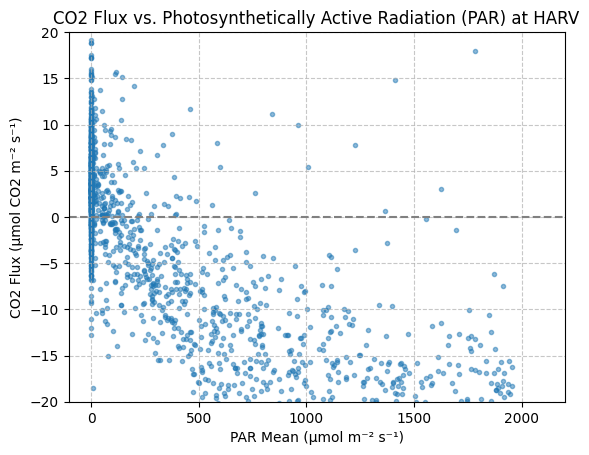

In [50]:
plt.scatter(fxpr_harv.PARMean,
            fxpr_harv['data.fluxCo2.nsae.flux'],
           marker='.', alpha=0.5)
plt.ylim((-20,20))
plt.title('CO2 Flux vs. Photosynthetically Active Radiation (PAR) at HARV')
plt.xlabel('PAR Mean (µmol m⁻² s⁻¹)')
plt.ylabel('CO2 Flux (µmol CO2 m⁻² s⁻¹)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='gray', linestyle='--') # Add a line at y=0 for sink/source reference
plt.show()

This cell calculates descriptive statistics for the PAR and CO2 flux data at the HARV site and then uses the `explain_plot` function (defined later) to generate an AI-driven explanation of the scatter plot's patterns and ecological implications. This helps in understanding the HARV site's carbon balance in detail.

This plot shows the relationship between PAR and CO2 flux for the HARV site, allowing for visual comparison with the NIWO site's carbon dynamics.

In [51]:
par_flux_harv_summary = fxpr_harv[['PARMean','data.fluxCo2.nsae.flux']].describe().to_string()
print(explain_plot(
    "scatter plot of PAR (photosynthetically active radiation) vs CO2 flux",
    par_flux_harv_summary,
    context=HARV_CONTEXT
))

Alright everyone, great work getting this plot generated! This scatter plot of Photosynthetically Active Radiation (PAR) against CO2 flux is fundamental to understanding how an ecosystem "breathes" carbon. Let's break down what we're seeing here for the HARV subalpine forest during June and July of 2018.

Remember, a negative CO2 flux means the ecosystem is taking up carbon from the atmosphere, and a positive flux means it's releasing carbon.

### 1. What pattern(s) are visible and why they make ecological sense

The plot clearly shows a classic **light response curve** of ecosystem CO2 exchange, often resembling a hyperbolic or parabolic shape.

*   **At low PAR (near 0 µmol m⁻² s⁻¹),** which corresponds to nighttime or heavily overcast conditions, the CO2 flux is predominantly **positive**. For example, the sample data rows show values like 7.06, 7.23, 9.87 µmol m⁻² s⁻¹ during the early morning hours (likely local night time). This makes perfect ecological sense:
    *   Without ligh

This prepares the data for a side-by-side boxplot comparison:
- `niwo_flux` and `harv_flux`: Extracts the CO2 flux data for each site and adds a 'Site' column to identify the origin of the data.
- `combined_flux = pd.concat([niwo_flux, harv_flux], ignore_index=True)`: Concatenates the two site-specific DataFrames into a single `combined_flux` DataFrame. `ignore_index=True` is crucial here to prevent duplicate indices, which caused a previous error.
- `combined_flux.rename(columns={'data.fluxCo2.nsae.flux': 'CO2_Flux'}, inplace=True)`: Renames the flux column for easier plotting.

Now that we have both plots and their interpretations, what are your observations? How does the carbon exchange at HARV compare to NIWO, and what further comparisons or analyses would you like to perform?

In [59]:
# Prepare data for side-by-side boxplot
niwo_flux = fxpr[['data.fluxCo2.nsae.flux']].copy()
niwo_flux['Site'] = 'NIWO'

harv_flux = fxpr_harv[['data.fluxCo2.nsae.flux']].copy()
harv_flux['Site'] = 'HARV'

combined_flux = pd.concat([niwo_flux, harv_flux], ignore_index=True)
combined_flux.rename(columns={'data.fluxCo2.nsae.flux': 'CO2_Flux'}, inplace=True)

This code generates a side-by-side boxplot comparing the distribution of CO2 flux values between the NIWO and HARV sites. Key elements:
- `plt.figure()`: Sets the figure size.
- `sns.boxplot(x='Site', y='CO2_Flux', data=combined_flux, palette='viridis')`: Creates the boxplot using the combined data, with 'Site' on the x-axis and 'CO2_Flux' on the y-axis.
- `plt.ylim((-20, 20))`: Ensures consistent y-axis limits for comparison.
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()`: Adds descriptive labels and title.
- `plt.grid()`, `plt.axhline(0, color='gray', linestyle='--')`: Adds a grid and a zero-line for reference.

/tmp/ipykernel_2201/3872336773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Site', y='CO2_Flux', data=combined_flux, palette='viridis')


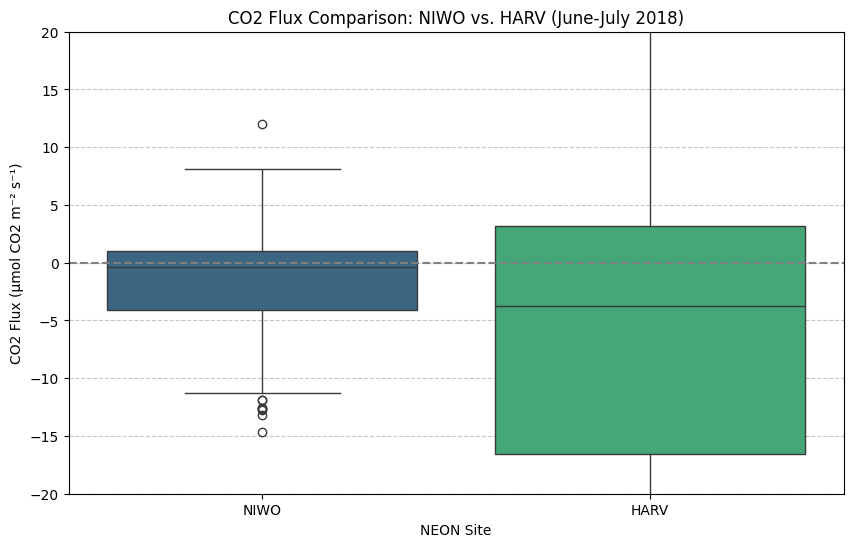

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Site', y='CO2_Flux', data=combined_flux, palette='viridis')
plt.ylim((-20, 20)) # Keep consistent y-axis limits for comparison
plt.title('CO2 Flux Comparison: NIWO vs. HARV (June-July 2018)')
plt.xlabel('NEON Site')
plt.ylabel('CO2 Flux (µmol CO2 m⁻² s⁻¹)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(0, color='gray', linestyle='--') # Add a line at y=0 for sink/source reference
plt.show()

This cell lists all available Gemini models that support the `generateContent` method. This is useful for checking which models are accessible and their exact names, which can be important for initializing the `GenerativeModel` correctly.

This boxplot visually compares the distribution of CO2 flux values between the NIWO and HARV sites during June-July 2018. The central line in each box represents the median, the box edges show the interquartile range (25th to 75th percentile), and the 'whiskers' extend to data points within 1.5 times the IQR. Points beyond the whiskers are outliers.

In [38]:
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

This defines the `ask_about_variable` function. This function takes a `variable_name` and a `context` (defaulting to `NEON_CONTEXT`) and crafts a prompt for the Gemini model. The model is asked to explain:
1. What the variable measures physically.
2. Its units and typical range.
3. Why an ecologist cares about it.
4. One thing a student should watch out for.
The function then returns the AI's generated explanation.

In [40]:
def ask_about_variable(variable_name, context=NEON_CONTEXT):
    prompt = f"""{context}

A student is asking about this specific variable in the dataset: `{variable_name}`

Please explain:
1. What this variable measures physically
2. Its units and typical range at this site
3. Why an ecologist would care about it
4. One thing a student should watch out for when interpreting it

Keep your answer concrete — reference the actual data statistics above where relevant.
"""
    response = model.generate_content(prompt)
    return response.text

This defines the `explain_plot` function. It takes a `plot_description`, `data_summary`, and `context` and uses the Gemini model to provide an ecological interpretation of a given plot. It asks the AI to explain:
1. Visible patterns and their ecological sense.
2. Drivers of variation.
3. Anything unusual or worth investigating.
4. What the pattern indicates about the ecosystem's carbon balance.
An example call is included that uses this function to explain the NIWO PAR vs. CO2 flux scatter plot.

In [41]:
def explain_plot(plot_description, data_summary, context=NEON_CONTEXT):
    prompt = f"""{context}

A student just made this plot:
PLOT DESCRIPTION: {plot_description}

DATA SHOWN IN PLOT:
{data_summary}

Please explain:
1. What pattern(s) are visible and why they make ecological sense
2. What is driving the diurnal or seasonal variation if present
3. One thing that looks unusual or worth investigating further
4. What this pattern tells us about this ecosystem's carbon balance

Be specific — use the actual values and site context above.
"""
    response = model.generate_content(prompt)
    return response.text

# Example call after making the PAR vs flux scatter:
par_flux_summary = fxpr[['PARMean','data.fluxCo2.nsae.flux']].describe().to_string()
explain_plot(
    "scatter plot of PAR (photosynthetically active radiation) vs CO2 flux",
    par_flux_summary
)

'Okay, this is a great starting point for analyzing the carbon dynamics of the Niwot Ridge subalpine forest! Let\'s break down what your plot likely shows and what it means.\n\nBased on the descriptive statistics for PAR and CO2 flux during June-July 2018, here\'s what we can infer about your scatter plot of PAR vs. CO2 flux:\n\n### 1. What pattern(s) are visible and why they make ecological sense\n\nThe plot likely shows a clear, non-linear relationship:\n\n*   **Positive CO2 Flux at Low PAR (Nighttime Respiration):** When PAR is near zero (nighttime or very cloudy conditions), the CO2 flux values are generally positive. The 75th percentile of CO2 flux is 0.986 µmol/m²/s, and the median is -0.362 µmol/m²/s, suggesting that a significant portion of the nighttime values are positive. This represents **ecosystem respiration** (Re) – the CO2 released by all living organisms (plants, microbes, animals) in the ecosystem when there\'s no light for photosynthesis. This makes perfect ecologica

This defines the `suggest_extensions` function. This function takes a description of `what_student_has_done` and a `context` and prompts the Gemini model to suggest three concrete next analyses. For each suggestion, the AI is asked to provide a title, explain the ecological question it answers, provide the exact Python/pandas code, and explain expected results. This helps guide further data exploration.

In [42]:
def suggest_extensions(what_student_has_done, context=NEON_CONTEXT):
    prompt = f"""{context}

A student has completed this analysis so far:
{what_student_has_done}

Suggest 3 concrete next analyses they could do with this dataset. For each:
- Give it a short title
- Explain the ecological question it answers
- Write the exact Python/pandas code to do it (using the variable names from the metadata above)
- Explain what result to expect and what it would mean

Prioritize ideas that are achievable with the variables already loaded and
that reveal something ecologically meaningful about carbon exchange at a subalpine site.
"""
    response = model.generate_content(prompt)
    return response.text

This cell calls the `ask_about_variable` function for the `data.fluxCo2.nsae.flux` variable, using the `NEON_CONTEXT`. It then prints the AI's detailed explanation of this key CO2 flux variable for the NIWO site.

In [43]:
print(ask_about_variable('data.fluxCo2.nsae.flux'))

Hello everyone! It's great you're diving into NEON's eddy covariance data – it's incredibly powerful for understanding ecosystem carbon cycling. Let's break down that specific variable: `data.fluxCo2.nsae.flux`.

---

Here's an explanation of `data.fluxCo2.nsae.flux` for the NIWO site in June–July 2018:

1.  **What this variable measures physically:**
    This variable measures the **Net Surface-Atmosphere Exchange (NSAE) of Carbon Dioxide (CO2)**. In simpler terms, it's the net movement of CO2 gas between the entire subalpine forest ecosystem (soil, plants, woody debris) and the atmosphere directly above it. The "NSAE" part is key: it means it accounts for both the rapid turbulent movement of CO2 and any changes in CO2 stored within the air column *below* the measurement height (known as "storage flux").
    *   **Negative values** (like -14.63 µmol CO2 m⁻² s⁻¹) indicate that the ecosystem is **taking up CO2** from the atmosphere. This primarily happens during the day due to photosynt